In [23]:
import pandas as pd
from pathlib import Path
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split, RepeatedStratifiedKFold
from sklearn.feature_selection import mutual_info_classif

from sklearn.model_selection import RepeatedStratifiedKFold, cross_validate
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import make_scorer, f1_score, precision_score, recall_score
from sklearn.neural_network import MLPClassifier
from sklearn.exceptions import ConvergenceWarning

import matplotlib.pyplot as plt
import seaborn as sns

In [24]:
# Suppress warnings
import warnings
warnings.filterwarnings('ignore', category=FutureWarning, module='seaborn') # seaborn's FutureWarning
warnings.filterwarnings('ignore', category=ConvergenceWarning) # sklearn's ConvergenceWarning


## Time recorder function 

--- 
To measure time for each model

In [25]:
# use real-time to measure the time to run a function

from time import process_time_ns

def time_operation(func):
    def wrapper(*args, **kwargs):
        start = process_time_ns()
        time_result = func(*args, **kwargs)
        end = process_time_ns()
        return time_result, (end - start) / 10**6 # milliseconds
    return wrapper

## 0. Load the cleaned data

---
After EDA, the cleaned data is saved in `car.parquet` 

In [26]:
data_path = Path().cwd().parent / "data" / "car.parquet"
df_car = pd.read_parquet(data_path)

In [27]:
df_car.shape

(1728, 7)

## Phase 1: Feature Engineering and Importance Analysis

#### 1.1. Mapping and Type Conversion

---
We will use manual mapping for the ordinal features to preserve their rank.

In [28]:
# 1. Manual Mapping for Ordinal Categories
ordinal_mappings = {
    'price': {'low': 1, 'med': 2, 'high': 3, 'vhigh': 4},
    'maintenance': {'low': 1, 'med': 2, 'high': 3, 'vhigh': 4},
    'storage': {'small': 1, 'med': 2, 'big': 3},
    'safety': {'low': 1, 'med': 2, 'high': 3},
    'shouldBuy': {'unacc': 0, 'acc': 1, 'good': 2, 'vgood': 3}
}

# Apply mappings
for col, map_dict in ordinal_mappings.items():
    df_car[col] = df_car[col].map(map_dict)

# 2. Cast Numeric-Categorical to Integers
df_car['doors'] = df_car['doors'].astype(int)
df_car['seats'] = df_car['seats'].astype(int)

# Verify no nulls were created by mistake during mapping
print(f"\nNull values per column after encoding:\n{df_car.isnull().sum()}")
print(f"\nNA values per column after encoding:\n{df_car.isna().sum()}")



Null values per column after encoding:
price          0
maintenance    0
doors          0
seats          0
storage        0
safety         0
shouldBuy      0
dtype: int64

NA values per column after encoding:
price          0
maintenance    0
doors          0
seats          0
storage        0
safety         0
shouldBuy      0
dtype: int64


#### 1.2. Feature Selection via Mutual Information
---
Since our dataset is small and non-linear, Mutual Information (MI) is better than a simple correlation matrix. MI captures any kind of statistical dependency between a feature and the label.

In [29]:
# 3. Calculate Information Gain using Mutual Information
X = df_car.drop('shouldBuy', axis=1)
y = df_car['shouldBuy']

# Calculate MI - we tell it all features are discrete (categorical integers)
importances = mutual_info_classif(X, y, discrete_features=True, random_state=42)

# Display results
feature_importance = pd.Series(importances, index=X.columns).sort_values(ascending=False)
print(f"Information Gain per Feature:=\n{feature_importance}")

Information Gain per Feature:=
safety         0.181732
seats          0.152259
price          0.066853
maintenance    0.051088
storage        0.020800
doors          0.003109
dtype: float64


Our feature importance analysis suggests that **safety** is the most important feature closely followed by **seats**. However, **doors** was the least important feature.

#### 1.3. Normalization (Min-Max Scaling)
---
Because we will use KNN and SVM later, we must scale the features. Without this, a feature with a range of 1–6 (seats) would mathematically outweigh a feature with a range of 1–3 (safety) simply because the numbers are larger.

In [30]:
scaler = MinMaxScaler()
# We scale only the features, not the label
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)

## Phase 2: Stratified Partitioning
---
To get a clean 80/10/10 split while maintaining the class balance (since "unacc" cars are so dominant), we will use a two-stage stratified split.

#### 2.1. Separate the "Hold-out" Test Set (10%)
---
First, we carve out 10% of the data. This data will be put in a "vault" and only used at the very end to see how the best model performs on truly unseen data.

In [31]:
# We take 10% for the final Test set
# Stratify=y is critical to keep the 'unacc'/'vgood' ratios identical
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X_scaled, y, 
    test_size=0.10, 
    random_state=42, 
    stratify=y
)

#### 2.2. Prepare the Training and Validation sets (80% / 10%)
----
For the remaining 90% of the data, we will use Stratified K-Fold cross-validation. Since we want a 10% validation size, we will set $K=9$
 - Math: If you have 9 parts, and you use 1 for validation, that 1 part is $11.1\%$ of the $90\%$, which equals exactly 10% of the original total dataset.

In [32]:
# Initialize the 9-fold splitter
# This allows us to train on 8 parts (80% total) and validate on 1 part (10% total)
rskf = RepeatedStratifiedKFold(n_splits=9, n_repeats=10, random_state=42)

print(f"Total records: {len(df_car)}")
print(f"Training/Val pool: {len(X_train_val)} records")
print(f"Final Test set: {len(X_test)} records")

Total records: 1728
Training/Val pool: 1555 records
Final Test set: 173 records


## Phase 3. Multi-algorithm Execution Loop
---
We will use `cross_validate` from Scikit-Learn. It is **superior** to `cross_val_score` because it allows us to track multiple metrics (Accuracy and F1-Score) and recording times simultaneously.

#### 3.1: The Tuning Engine (KNN)First
---
We define a function to find the best $K$. This uses our time_operation decorator to track the search efficiency.

In [33]:
def tune_knn_neighbors(X, y, cv_strategy, k_values=range(1, 21), chosen_metric='f1_mean'):
    """Finds the best K for KNN and returns the optimized model and all results."""
    print(f"Sub-Phase 3.1: Tuning KNN for K in {k_values}...")
    
    all_results = {}
    
    for k in k_values:
        model = KNeighborsClassifier(n_neighbors=k)
        timed_cv = time_operation(cross_validate)
        cv_res, duration = timed_cv(model, X, y, cv=cv_strategy, 
                                   scoring='f1_macro', n_jobs=-1)
        
        all_results[k] = {
            "model": f"KNN_{k}",
            "f1_mean": float(cv_res['test_score'].mean()),
            "f1_std": float(cv_res['test_score'].std()),
            "accuracy_mean": float(cv_res['test_score'].mean()),
            "accuracy_std": float(cv_res['test_score'].std()),
            "precision_mean": float(cv_res['test_score'].mean()),
            "precision_std": float(cv_res['test_score'].std()),
            "recall_mean": float(cv_res['test_score'].mean()),
            "recall_std": float(cv_res['test_score'].std()),
            "time": float(duration),
            "cv_folds": len(cv_res['test_score']),
            "_sort_key": float(cv_res['test_score'].mean()),
        }
    
    # Find best K
    best_k = max(all_results.items(), key=lambda x: x[1][chosen_metric])[0]
    best_metric = all_results[best_k][chosen_metric]
    
    
    print(f"--- Best K: {best_k} ({chosen_metric}: {all_results[best_k][chosen_metric]:.4f}) ---\n")
    print("All results for KNN:=")
    df_knn_result = pd.DataFrame.from_dict(all_results, orient='index')
    df_knn_result = df_knn_result.sort_values(by=chosen_metric, ascending=False)
    display(df_knn_result)

    return best_k, all_results

#### 3.2: The Cross-Validation Engine
---
This function takes our list of models and runs them through the Repeated Stratified K-Fold. It returns a raw list of results that we can use for plotting later.

In [34]:
def evaluate_all_models(models_dict, X, y, cv_strategy):
    """Runs repeated cross-validation on a dictionary of models.
    Returns all results as a dictionary."""
    print("Sub-Phase 3.2: Executing Multi-Algorithm Comparison...")
    
    # Define custom scorers to handle the zero_division warning
    # setting zero_division=0 suppresses the warning and keeps the score at 0.0
    custom_scoring = {
        'accuracy': 'accuracy',
        'f1_macro': make_scorer(f1_score, average='macro', zero_division=0),
        'precision_macro': make_scorer(precision_score, average='macro', zero_division=0),
        'recall_macro': make_scorer(recall_score, average='macro', zero_division=0)
    }

    all_results = {}
    
    for name, model in models_dict.items():
        print(f"   Testing: {name}...")
        
        timed_cv = time_operation(cross_validate)
        cv_results, duration = timed_cv(
            model, X, y, 
            cv=cv_strategy, 
            scoring=custom_scoring,
            n_jobs=-1
        )
        
        all_results[name] = {
            "metrics": {
                "f1": {
                    "mean": float(cv_results['test_f1_macro'].mean()),
                    "std": float(cv_results['test_f1_macro'].std()),
                    "scores": cv_results['test_f1_macro'].tolist()
                },
                "accuracy": {
                    "mean": float(cv_results['test_accuracy'].mean()),
                    "std": float(cv_results['test_accuracy'].std()),
                    "scores": cv_results['test_accuracy'].tolist()
                },
                "precision": {
                    "mean": float(cv_results['test_precision_macro'].mean()),
                    "std": float(cv_results['test_precision_macro'].std()),
                    "scores": cv_results['test_precision_macro'].tolist()
                },
                "recall": {
                    "mean": float(cv_results['test_recall_macro'].mean()),
                    "std": float(cv_results['test_recall_macro'].std()),
                    "scores": cv_results['test_recall_macro'].tolist()
                }
            },
            "time": duration,
            "model": model,
            "cv_folds": len(cv_results['test_f1_macro'])
        }
    
    return all_results

#### 3.3: The Master Execution
---
Now we bring it all together. This is the only part of the code you "run" to trigger the entire process.

In [35]:
# 1. Find optimal K (Sub-Phase 3.1)
best_k, all_knn_results = tune_knn_neighbors(X_train_val, y_train_val, rskf, chosen_metric='f1_mean')

# 2. Define Final Model Dictionary
model_suite = {
    f"NaiveBayes": GaussianNB(),
    f"KNN_(K={best_k})": KNeighborsClassifier(n_neighbors=best_k),
    "SVM_Linear": SVC(kernel='linear', class_weight='balanced', probability=True),
    "SVM_RBF": SVC(kernel='rbf', class_weight='balanced', probability=True),
    "RandomForest": RandomForestClassifier(class_weight='balanced', max_depth=10, random_state=42),
    "XGBoost": XGBClassifier(random_state=42),
    "ANN": MLPClassifier(
        hidden_layer_sizes=(12, 8), 
        activation="relu", 
        solver="adam", 
        max_iter=1000, 
        random_state=42,
        # early_stopping=True,
        # n_iter_no_change=10,
        verbose=False
    )
}


# 3. Run Evaluation (Sub-Phase 3.2)
raw_results = evaluate_all_models(model_suite, X_train_val, y_train_val, rskf)


# 4. Build Numeric Summary Dictionary (Storing ACTUAL values)
summary_dict = {}
for name, data in raw_results.items():
    m = data['metrics']
    summary_dict[name] = {
        "accuracy_mean": m['accuracy']['mean'],
        "accuracy_std": m['accuracy']['std'],
        "precision_mean": m['precision']['mean'],
        "precision_std": m['precision']['std'],
        "recall_mean": m['recall']['mean'],
        "recall_std": m['recall']['std'],
        "f1_mean": m['f1']['mean'],
        "f1_std": m['f1']['std'],
        "time_(ms)": data['time'],
        "_sort_key": m['accuracy']['mean'],
    }

# 6. Create Pandas DataFrame for Phase 4
# orient='index' uses the model names as rows
results_df = pd.DataFrame.from_dict(summary_dict, orient='index')

# Sort by F1 numeric value then drop the helper column
results_df = results_df.sort_values(by="_sort_key").drop(columns=["_sort_key"])

print("\n--- PHASE 3.3 FINAL SUMMARY ---")
display(results_df)

Sub-Phase 3.1: Tuning KNN for K in range(1, 21)...
--- Best K: 3 (f1_mean: 0.8421) ---

All results for KNN:=


,model,f1_mean,f1_std,accuracy_mean,accuracy_std,precision_mean,precision_std,recall_mean,recall_std,time,cv_folds,_sort_key
3,KNN_3,0.842083,0.051990,0.842083,0.051990,0.842083,0.051990,0.842083,0.051990,210.226798,90,0.842083
15,KNN_15,0.840557,0.054816,0.840557,0.054816,0.840557,0.054816,0.840557,0.054816,210.512876,90,0.840557
13,KNN_13,0.839813,0.061293,0.839813,0.061293,0.839813,0.061293,0.839813,0.061293,204.860406,90,0.839813
14,KNN_14,0.836940,0.056076,0.836940,0.056076,0.836940,0.056076,0.836940,0.056076,161.227589,90,0.836940
17,KNN_17,0.835477,0.057890,0.835477,0.057890,0.835477,0.057890,0.835477,0.057890,256.294255,90,0.835477
1,KNN_1,0.833665,0.046773,0.833665,0.046773,0.833665,0.046773,0.833665,0.046773,209.329383,90,0.833665
16,KNN_16,0.831958,0.058994,0.831958,0.058994,0.831958,0.058994,0.831958,0.058994,212.891887,90,0.831958
11,KNN_11,0.828496,0.059000,0.828496,0.059000,0.828496,0.059000,0.828496,0.059000,208.437330,90,0.828496
12,KNN_12,0.825362,0.057451,0.825362,0.057451,0.825362,0.057451,0.825362,0.057451,190.860966,90,0.825362
18,KNN_18,0.824218,0.067126,0.824218,0.067126,0.824218,0.067126,0.824218,0.067126,229.494075,90,0.824218


Sub-Phase 3.2: Executing Multi-Algorithm Comparison...
   Testing: NaiveBayes...
   Testing: KNN_(K=3)...
   Testing: SVM_Linear...
   Testing: SVM_RBF...
   Testing: RandomForest...
   Testing: XGBoost...
   Testing: ANN...

--- PHASE 3.3 FINAL SUMMARY ---


,accuracy_mean,accuracy_std,precision_mean,precision_std,recall_mean,recall_std,f1_mean,f1_std,time_(ms)
NaiveBayes,0.694609,0.026751,0.558163,0.095250,0.568034,0.040503,0.437102,0.052404,266.816388
SVM_Linear,0.805013,0.031012,0.663443,0.047361,0.849151,0.046439,0.722217,0.047115,227.216452
KNN_(K=3),0.928231,0.018438,0.876593,0.053561,0.825243,0.059827,0.842083,0.051990,228.608693
SVM_RBF,0.928680,0.020456,0.883470,0.041382,0.955748,0.024043,0.912593,0.033362,244.261536
ANN,0.949324,0.016467,0.906975,0.040511,0.910759,0.042653,0.904242,0.038245,364.268479
RandomForest,0.976722,0.012673,0.942834,0.038257,0.959144,0.033357,0.948198,0.034360,276.704833
XGBoost,0.994405,0.005556,0.985376,0.019725,0.986938,0.017481,0.985280,0.016488,355.456334


In [36]:
# save model suite in the results directory for future testing purpose
import joblib
results_dir = Path().cwd().parent / "results"
results_dir.mkdir(exist_ok=True)
model_suite_path = results_dir / "model_suite.pkl"
joblib.dump(model_suite, model_suite_path)
print(f"\nModel suite saved to: {model_suite_path}")


Model suite saved to: /home/bhavik/Dropbox/edu/smu/winter/data_mining/a2_classification/mcda5580-data-mining-a2-classification/results/model_suite.pkl


## Phase 4: Data Visualization
---
The results discussion and Data Visualization

#### 4.1. Model Stability Analysis (F1-Score Boxplots)
---
The "Mean ± SD" in our table tells part of the story, but a boxplot shows the distribution. If a model has a wide box, it is inconsistent across different shuffles of our car data.

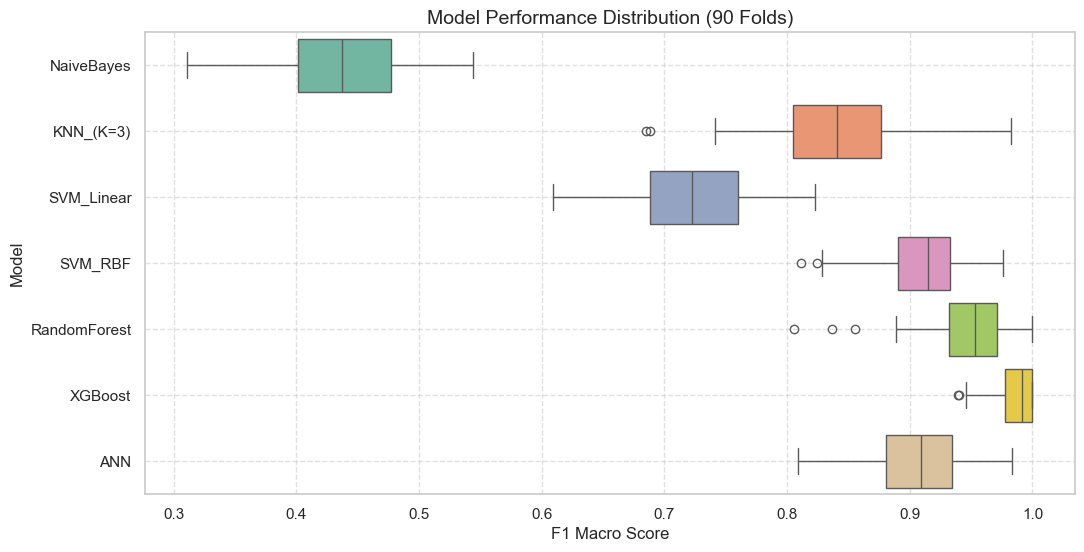

<Figure size 640x480 with 0 Axes>

In [37]:
# Extract scores from the nested dictionary for Seaborn
plot_data = []
for model_name, data in raw_results.items():
    f1_scores = data['metrics']['f1']['scores']
    for score in f1_scores:
        plot_data.append({"Model": model_name, "F1 Macro Score": score})

plot_df = pd.DataFrame(plot_data)

results_path = Path().cwd().parent / "results"

# Visualization
plt.figure(figsize=(12, 6))
sns.boxplot(x='F1 Macro Score', y='Model', data=plot_df, palette="Set2", hue="Model")
plt.title("Model Performance Distribution (90 Folds)", fontsize=14)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()
plt.savefig(results_path / 'model_performance_distribution.png')

#### 4.2. Efficiency Trade-off (Performance vs. Time)
---
An ANN or XGBoost might be accurate, but are they worth the extra CPU time compared to a Random Forest?

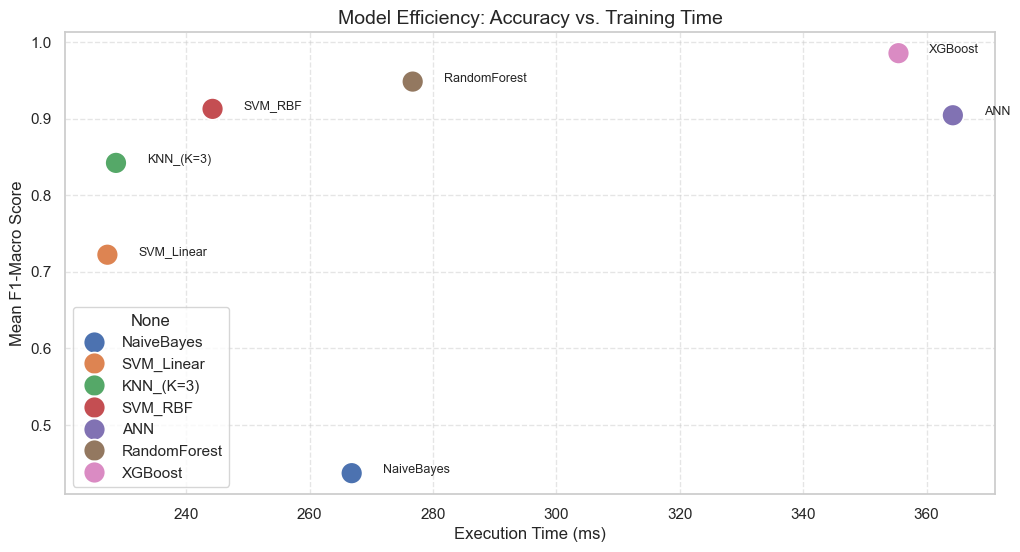

In [38]:
# Use the summary results_df we created in Phase 3.3
plt.figure(figsize=(12, 6))

# 1. Ensure numeric consistency for plotting
sns.scatterplot(
    data=results_df, 
    x='time_(ms)',   
    y='f1_mean',     
    hue=results_df.index, 
    s=250,
    legend='full'
)

# Annotate points with model names
for idx, row in results_df.iterrows():
    plt.text(row['time_(ms)'] + 5, row['f1_mean'], idx, 
             fontsize=9, fontweight='medium')

plt.title("Model Efficiency: Accuracy vs. Training Time", fontsize=14)
plt.xlabel("Execution Time (ms)")
plt.ylabel("Mean F1-Macro Score")
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

## Phase 5: Final Testing & Generalization
---
Before training, we have taken 10% of our dataset out, for the testing. This is unknown data, which haven't been use during training/validation phase.


#### 5.1 Final fitting and prediction

We will iterate through your `model_suite` dictionary, train each model, and store the final test results in a new dictionary.

In [39]:
from sklearn.metrics import classification_report, f1_score, accuracy_score

# 1. Dictionary to hold all final testing metrics
test_results = {}

for name, model in model_suite.items():
    print(f"   Finalizing {name}...")
    
    # Train on the FULL 90% Training/Validation pool
    model.fit(X_train_val, y_train_val)
    
    # Predict on the 10% Test set
    y_pred = model.predict(X_test)


    # Calculate all Test metrics
    test_f1 = f1_score(y_test, y_pred, average='macro')
    test_acc = accuracy_score(y_test, y_pred)
    test_prec = precision_score(y_test, y_pred, average='macro', zero_division=0)
    test_rec = recall_score(y_test, y_pred, average='macro', zero_division=0)

    test_results[name] = {
        "test_f1": test_f1,
        "test_accuracy": test_acc,
        "test_precision": test_prec,
        "test_recall": test_rec,
        "classification_report": classification_report(y_test, y_pred),
        "y_pred": y_pred  # Store predictions for confusion matrix later
    }
    


   Finalizing NaiveBayes...
   Finalizing KNN_(K=3)...
   Finalizing SVM_Linear...
   Finalizing SVM_RBF...
   Finalizing RandomForest...
   Finalizing XGBoost...
   Finalizing ANN...


#### 5.2 Comparison: Training vs. Testing
A critical part of our report is checking for overfitting. If a model got 99% in Phase-3 but gets 70% here, it failed to generalize.

In [40]:
# 2. Build a comparison table
final_result_comparison = {}

for name, model in model_suite.items():
    # Final predictions from fitted models
    y_pred = test_results[name]['y_pred']
    
    # Calculate all Test metrics
    test_f1 = f1_score(y_test, y_pred, average='macro')
    test_acc = accuracy_score(y_test, y_pred)
    test_prec = precision_score(y_test, y_pred, average='macro', zero_division=0)
    test_rec = recall_score(y_test, y_pred, average='macro', zero_division=0)
    
    # Map CV means from your results_df and Test metrics into the dictionary
    final_result_comparison[name] = {
        "F1_CV": results_df.loc[name, 'f1_mean'],
        "F1_Test": test_f1,
        "Acc_CV": results_df.loc[name, 'accuracy_mean'],
        "Acc_Test": test_acc,
        "Prec_CV": results_df.loc[name, 'precision_mean'],
        "Prec_Test": test_prec,
        "Rec_CV": results_df.loc[name, 'recall_mean'],
        "Rec_Test": test_rec
    }

# 2. Create the Comparison DataFrame
final_comp_df = pd.DataFrame.from_dict(final_result_comparison, orient='index')

# 3. Format the display to show the "Delta" (Generalization Gap)
print("\n--- COMPREHENSIVE METRIC COMPARISON (Cross Validation vs. TEST) ---")

# Sort by Test F1 to see the real-world winner
final_comp_df = final_comp_df.sort_values(by="F1_Test", ascending=False)
print(final_comp_df.to_string(float_format=lambda x: f"{x:.4f}"))



--- COMPREHENSIVE METRIC COMPARISON (Cross Validation vs. TEST) ---
              F1_CV  F1_Test  Acc_CV  Acc_Test  Prec_CV  Prec_Test  Rec_CV  Rec_Test
XGBoost      0.9853   0.9775  0.9944    0.9942   0.9854     0.9936  0.9869    0.9643
RandomForest 0.9482   0.9715  0.9767    0.9827   0.9428     0.9559  0.9591    0.9893
ANN          0.9042   0.9167  0.9493    0.9538   0.9070     0.8997  0.9108    0.9363
SVM_RBF      0.9126   0.8613  0.9287    0.8786   0.8835     0.8104  0.9557    0.9386
KNN_(K=3)    0.8421   0.7477  0.9282    0.8902   0.8766     0.8315  0.8252    0.7228
SVM_Linear   0.7222   0.6724  0.8050    0.7457   0.6634     0.6021  0.8492    0.8369
NaiveBayes   0.4371   0.3522  0.6946    0.6705   0.5582     0.3751  0.5680    0.5023


#### 5.3 Plot the results
---
1. Cross Validation vs Test Metric comparisons
2. Confusion Matrix

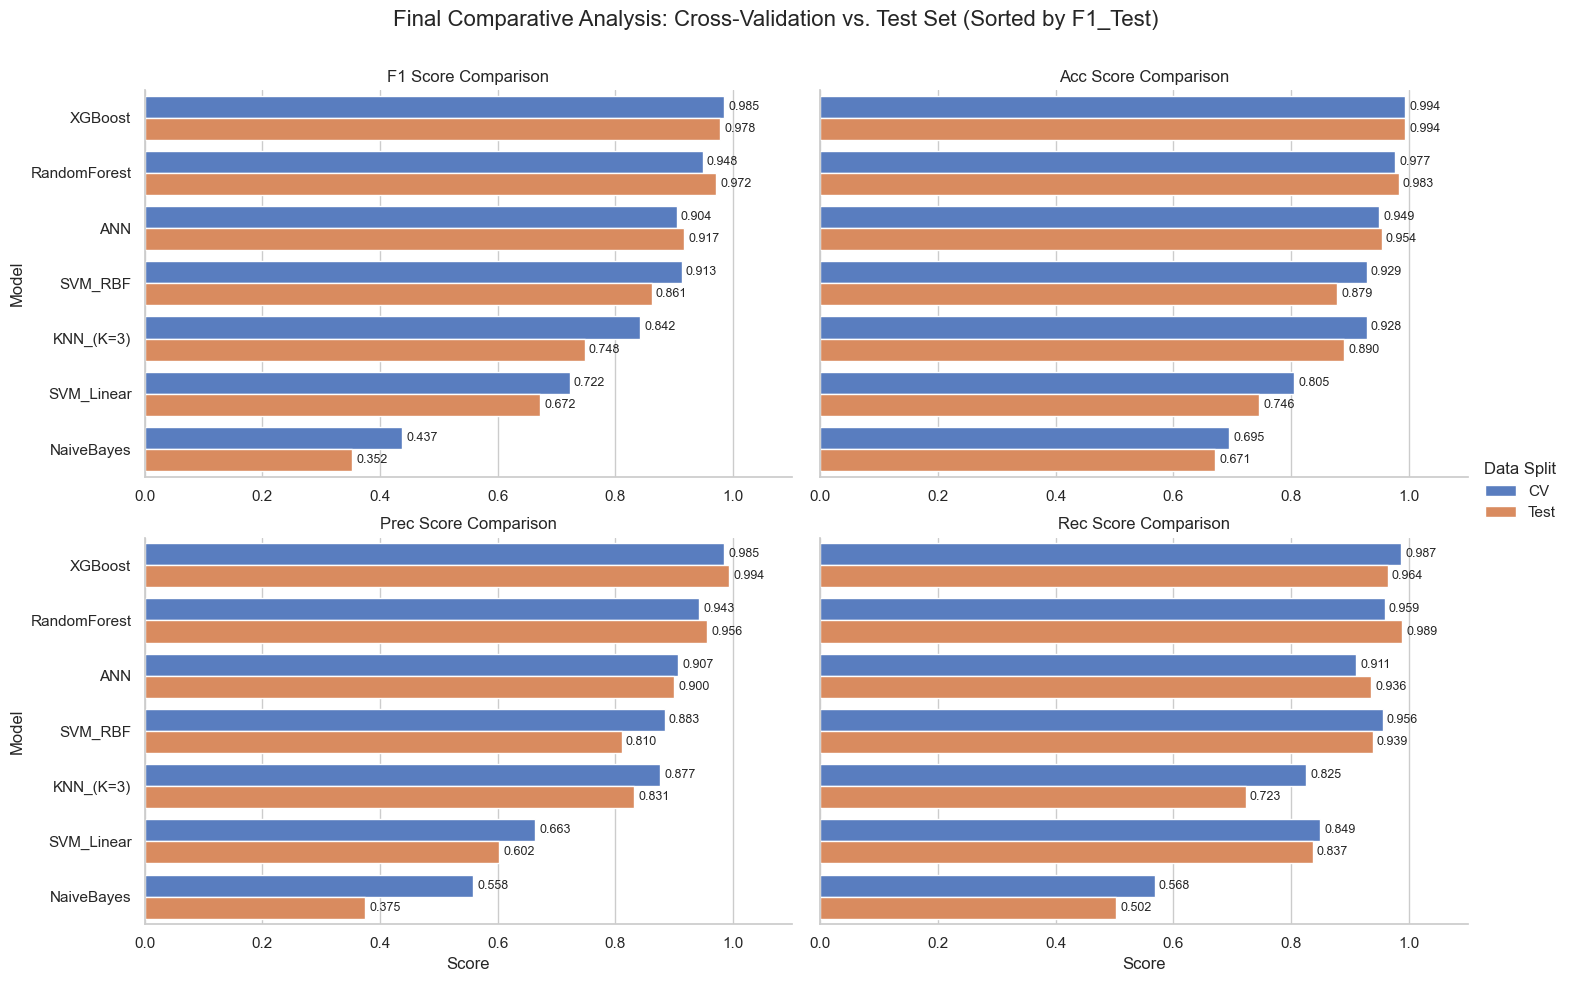

In [41]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Re-structuring the data into a long-form format for Seaborn
plot_data = []

for model_name, metrics in final_result_comparison.items():
    # Capture all 4 metric pairs
    for metric_name in ['F1', 'Acc', 'Prec', 'Rec']:
        plot_data.append({
            "Model": model_name, 
            "Metric": metric_name, 
            "Type": "CV", 
            "Score": metrics[f'{metric_name}_CV']
        })
        plot_data.append({
            "Model": model_name, 
            "Metric": metric_name, 
            "Type": "Test", 
            "Score": metrics[f'{metric_name}_Test']
        })

viz_df = pd.DataFrame(plot_data)

# 2. SORTING: Create a sorting order based on F1_Test
# This ensures the charts are organized and professional
model_order = (
    viz_df[(viz_df['Metric'] == 'F1') & (viz_df['Type'] == 'Test')]
    .sort_values(by='Score', ascending=False)['Model']
    .tolist()
)

# 3. Create the Multi-Plot Visualization
sns.set_theme(style="whitegrid")
g = sns.FacetGrid(
    viz_df, 
    col="Metric", 
    col_wrap=2, 
    height=5, 
    aspect=1.5, 
    sharex=False
)

# Use the 'row_order' to keep consistency across all 4 charts
g.map_dataframe(
    sns.barplot, 
    x="Score", 
    y="Model", 
    hue="Type", 
    order=model_order, 
    palette="muted"
)

# 4. Formatting and Annotations
g.add_legend(title="Data Split")
g.set_titles("{col_name} Score Comparison")
g.set(xlim=(0, 1.1))

for ax in g.axes.flat:
    for container in ax.containers:
        ax.bar_label(container, fmt='%.3f', padding=3, fontsize=9)

plt.subplots_adjust(top=0.9)
plt.suptitle('Final Comparative Analysis: Cross-Validation vs. Test Set (Sorted by F1_Test)', fontsize=16)

plt.show()

Saving diagnostic plots to: /home/bhavik/Dropbox/edu/smu/winter/data_mining/a2_classification/mcda5580-data-mining-a2-classification/results


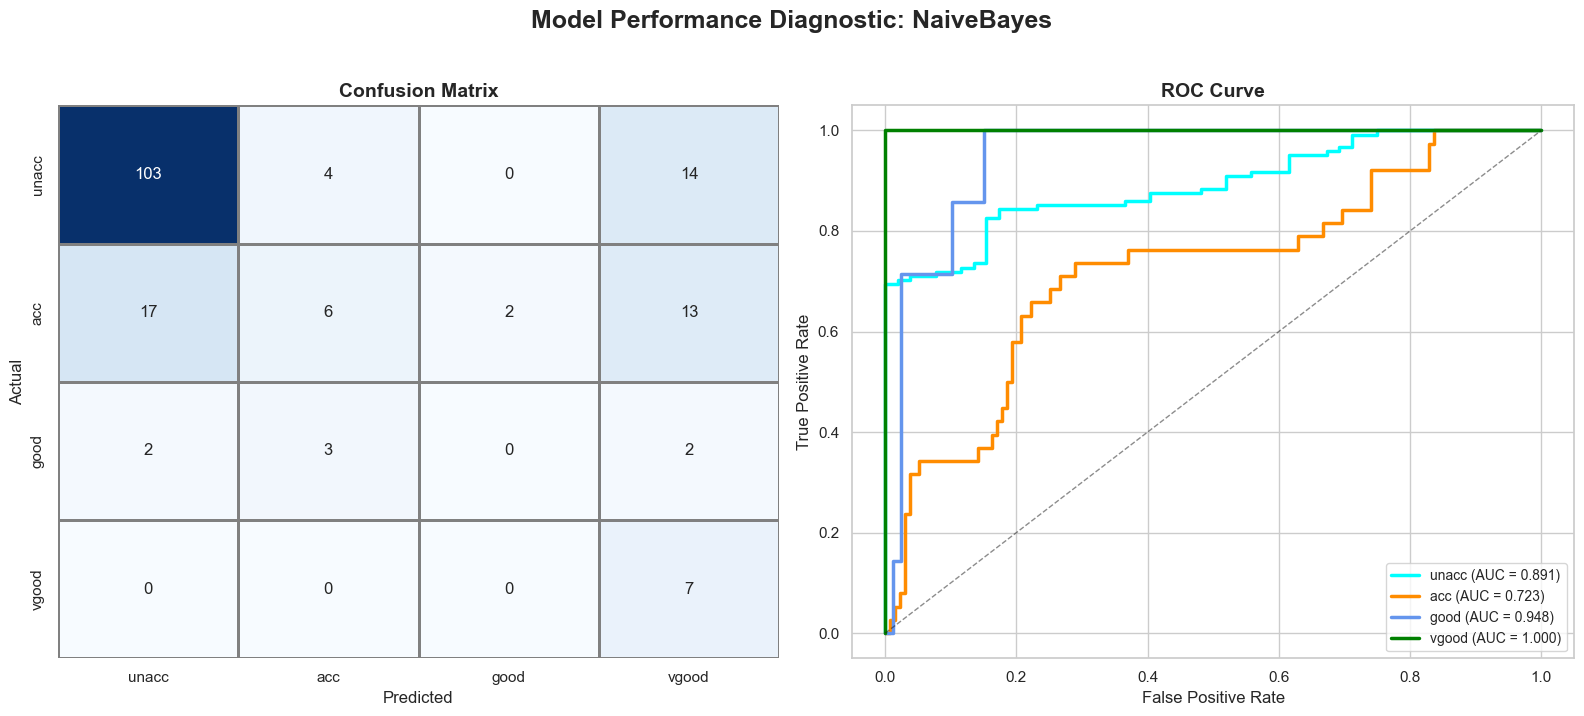

   Successfully saved: diagnostic_NaiveBayes.png


<Figure size 640x480 with 0 Axes>

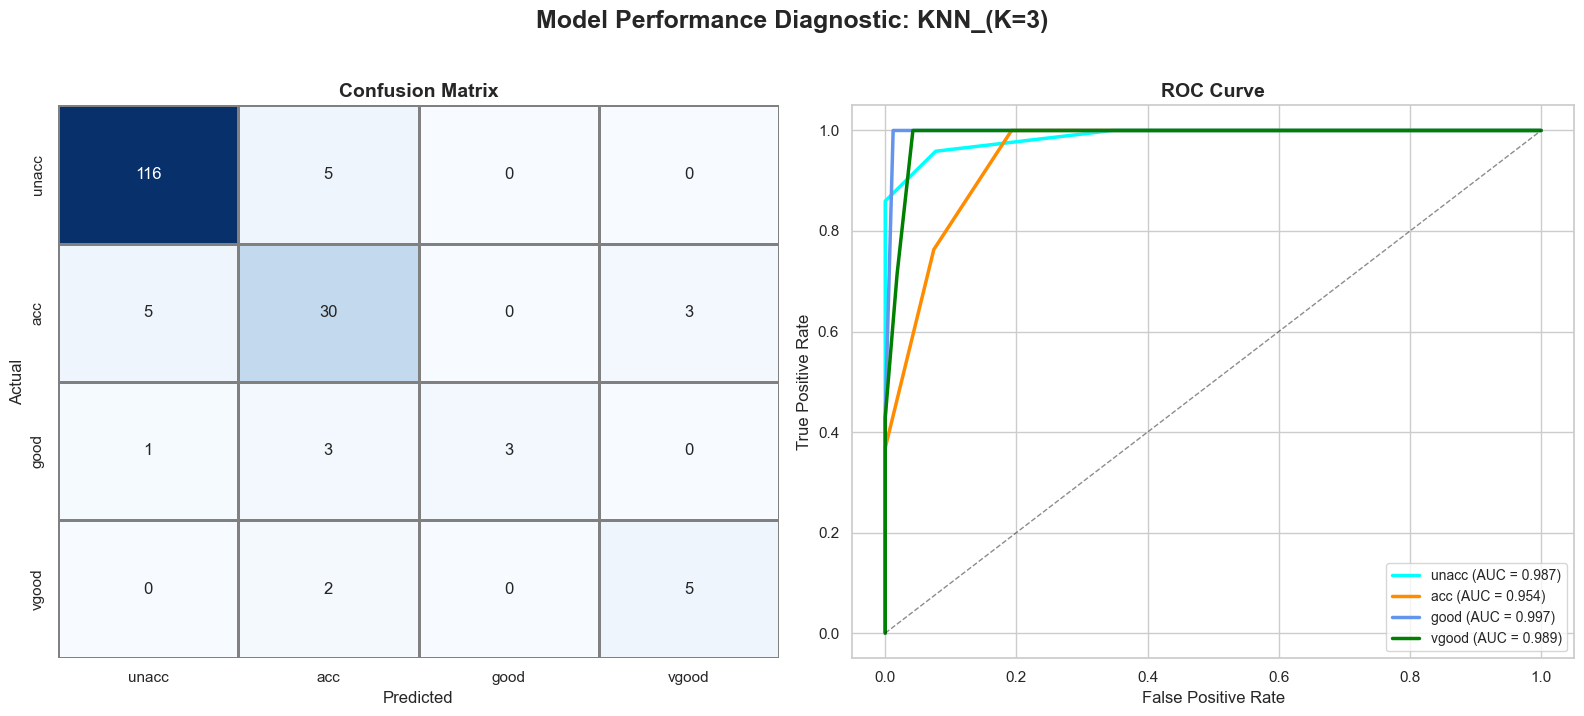

   Successfully saved: diagnostic_KNN_K3.png


<Figure size 640x480 with 0 Axes>

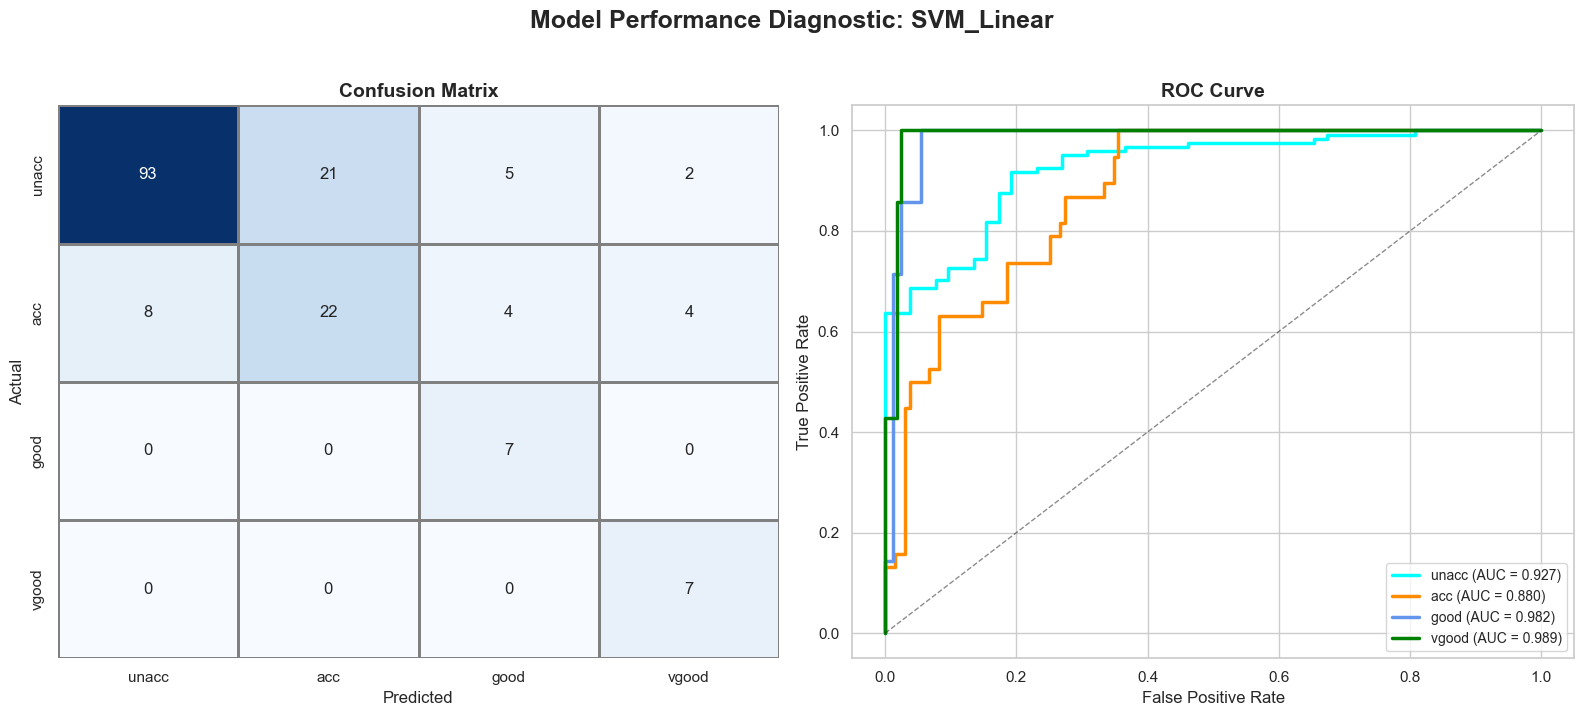

   Successfully saved: diagnostic_SVM_Linear.png


<Figure size 640x480 with 0 Axes>

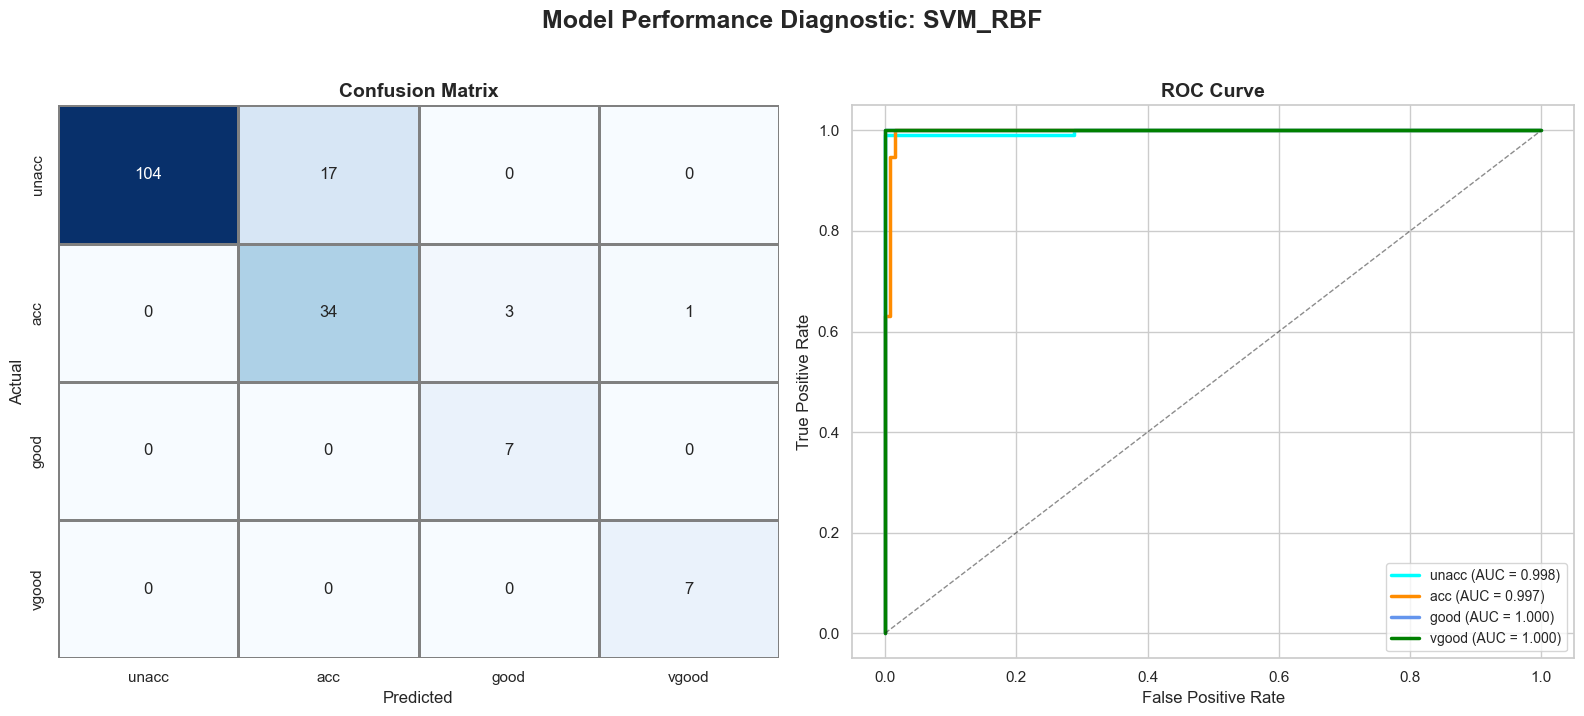

   Successfully saved: diagnostic_SVM_RBF.png


<Figure size 640x480 with 0 Axes>

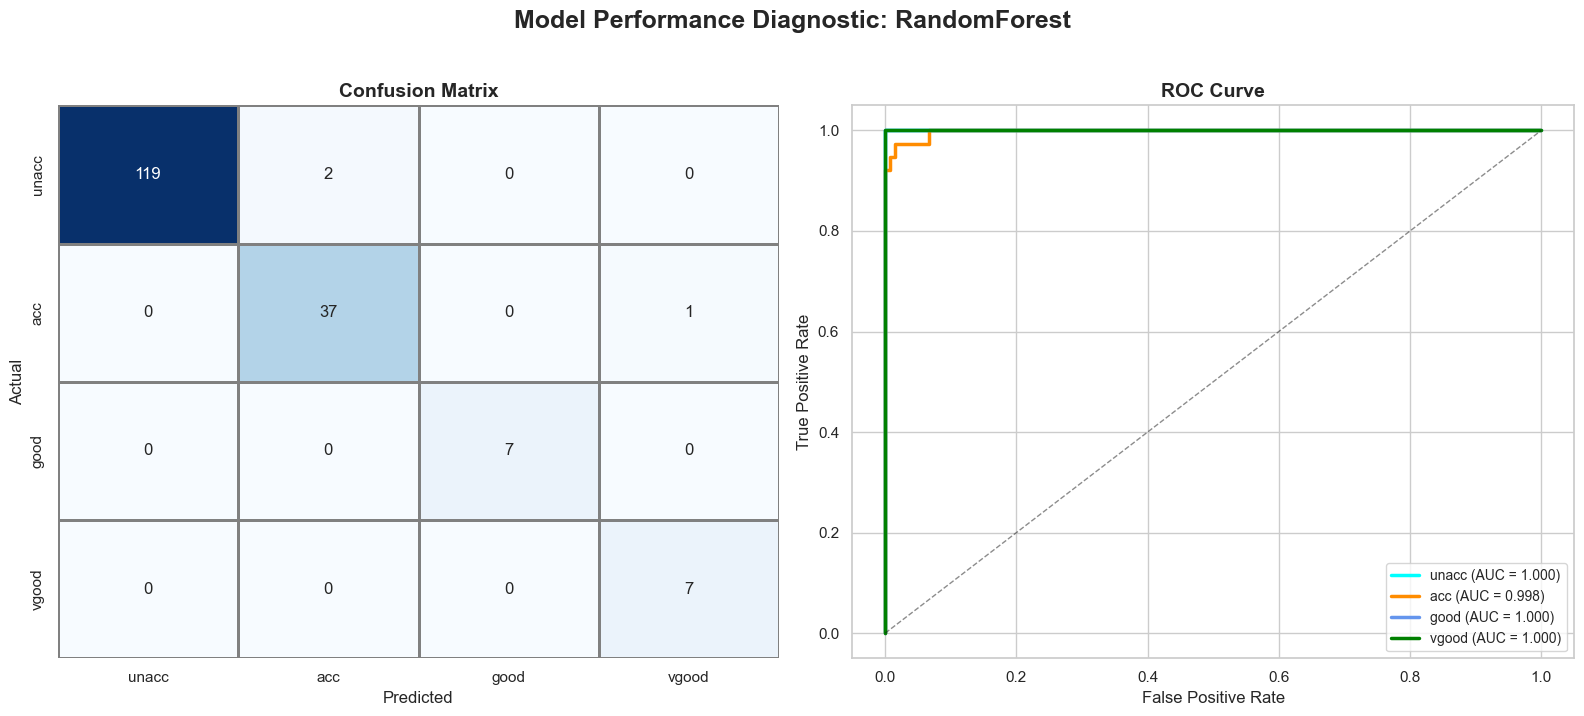

   Successfully saved: diagnostic_RandomForest.png


<Figure size 640x480 with 0 Axes>

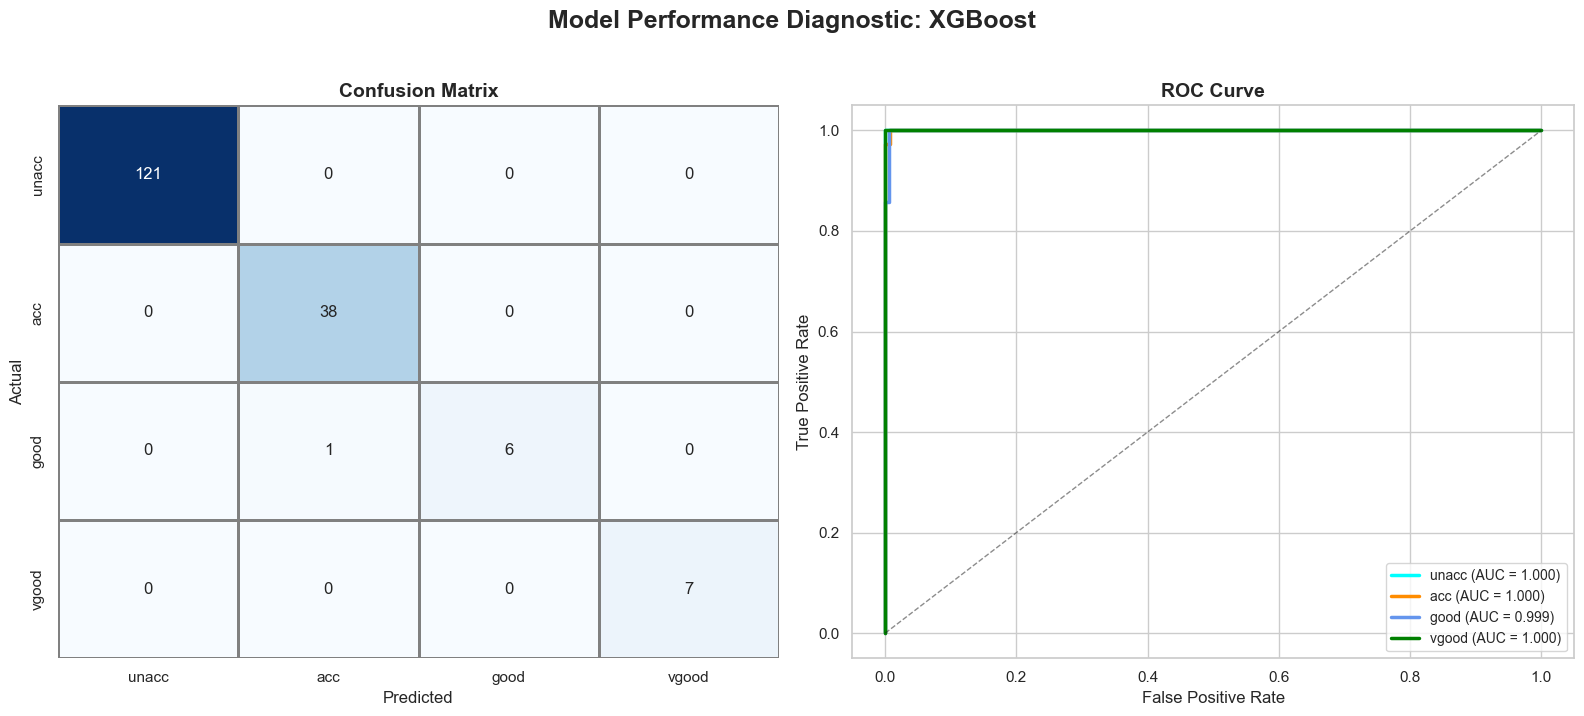

   Successfully saved: diagnostic_XGBoost.png


<Figure size 640x480 with 0 Axes>

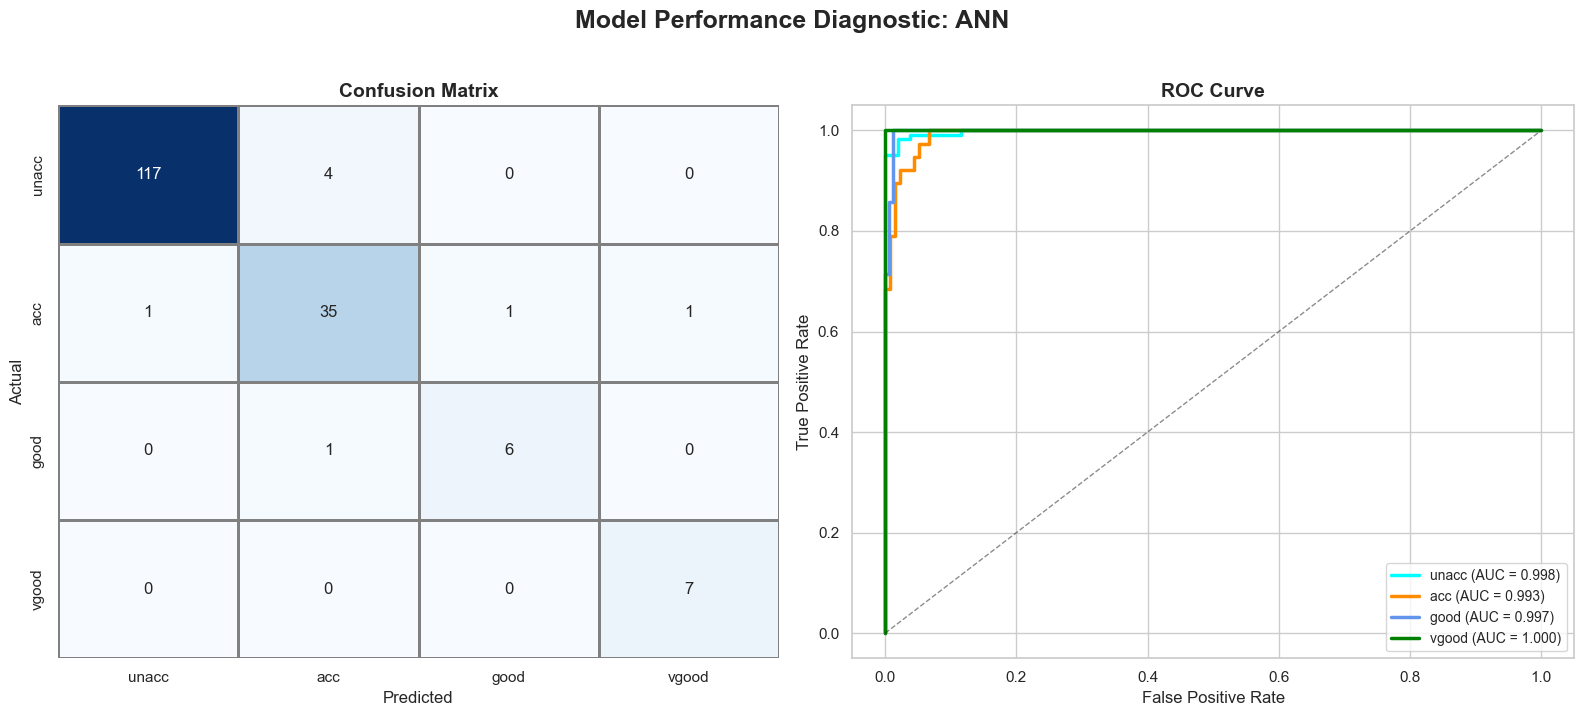

   Successfully saved: diagnostic_ANN.png

All diagnostics have been exported.


<Figure size 640x480 with 0 Axes>

In [42]:
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, roc_curve, auc
from sklearn.preprocessing import label_binarize

# 1. Setup the directory path
# Moving from code/ to results/
results_dir = Path.cwd().parent / "results"
results_dir.mkdir(parents=True, exist_ok=True)

# Data setup
class_names = ['unacc', 'acc', 'good', 'vgood']
y_test_bin = label_binarize(y_test, classes=[0, 1, 2, 3])

print(f"Saving diagnostic plots to: {results_dir}")

# 2. Loop through each model to create individual diagnostic cards
for name, model_info in test_results.items():
    # Create a fresh figure for each model
    fig, (ax_cm, ax_roc) = plt.subplots(1, 2, figsize=(16, 7))
    plt.subplots_adjust(wspace=0.3)
    
    # Model objects and predictions
    actual_model = model_suite[name]
    y_pred = model_info['y_pred']
    y_score = actual_model.predict_proba(X_test)
    
    # --- A. Confusion Matrix (Left) ---
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax_cm,
                xticklabels=class_names, yticklabels=class_names, 
                cbar=False, linewidths=1, linecolor='gray')
    ax_cm.set_title(f"Confusion Matrix", fontsize=14, fontweight='bold')
    ax_cm.set_ylabel('Actual')
    ax_cm.set_xlabel('Predicted')

    # --- B. ROC Curve (Right) ---
    colors = ['aqua', 'darkorange', 'cornflowerblue', 'green']
    for i, color in zip(range(len(class_names)), colors):
        fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
        roc_auc = auc(fpr, tpr)
        ax_roc.plot(fpr, tpr, color=color, lw=2.5,
                    label=f'{class_names[i]} (AUC = {roc_auc:.3f})')
    
    ax_roc.plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.5)
    ax_roc.set_title(f"ROC Curve", fontsize=14, fontweight='bold')
    ax_roc.set_xlabel('False Positive Rate')
    ax_roc.set_ylabel('True Positive Rate')
    ax_roc.legend(loc="lower right", fontsize=10)

    # Styling the overall card
    fig.suptitle(f"Model Performance Diagnostic: {name}", fontsize=18, fontweight='bold', y=1.02)
    plt.tight_layout()
    
    # 3. Save the result
    # Sanitize name for filename (removing spaces/brackets)
    clean_name = name.replace(" ", "_").replace("(", "").replace(")", "").replace("=", "")
    save_path = results_dir / f"diagnostic_{clean_name}.png"
    
    plt.show()
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.close(fig) # Close to save memory
    print(f"   Successfully saved: {save_path.name}")

print("\nAll diagnostics have been exported.")
